# Dendrogram of Codebooks Across Versions

This notebook reads the step-2 codification outputs from each version, extracts one text per codebook entry (`code_name + description`), embeds them with a local model, caches the embeddings to disk, computes a density-preserving UMAP projection, tunes HDBSCAN on that projected space, and then visualizes the resulting structure.

## Plan

1. Build a dataloader for all `codification_analysis.json` files.
2. Load a local embedding model.
3. Create or reuse a JSON cache of code embeddings.
4. Compute a density-preserving UMAP projection and tune HDBSCAN on it.
5. Visualize the projected clusters and inspect the hierarchy with a dendrogram.

In [237]:
# Optional installs for a fresh notebook kernel
%pip install -q sentence-transformers umap-learn hdbscan scipy scikit-learn matplotlib seaborn pandas plotly


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 1 — Data Loader

This section discovers every version folder, reads its step-2 codification output, and flattens the `codebook` entries into one analysis table.

Each row represents one code in one version, with a single text field built from the code name and the description.

In [238]:
from __future__ import annotations

import json
from pathlib import Path

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import requests
import seaborn as sns
from IPython.display import HTML, display
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from umap import UMAP

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

REPO_ROOT = Path.cwd()
DATA_ROOT = REPO_ROOT / "data"
CACHE_DIR = DATA_ROOT / "ALL_VERSIONS" / "embedding_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

OLLAMA_MODEL = "qwen3-embedding:0.6b"
OLLAMA_URL = "http://localhost:11434/api/embed"
EMBED_CACHE_PATH = CACHE_DIR / "codebook_embeddings_qwen3_0_6b.json"
CLUSTER_CACHE_PATH = CACHE_DIR / "codebook_hdbscan_results_qwen3_0_6b.json"

print(f"Repo root: {REPO_ROOT}")
print(f"Ollama endpoint: {OLLAMA_URL}")
print(f"Embedding cache: {EMBED_CACHE_PATH}")

Repo root: /Users/adnenkhiari/Documents/nawnaw
Ollama endpoint: http://localhost:11434/api/embed
Embedding cache: /Users/adnenkhiari/Documents/nawnaw/data/ALL_VERSIONS/embedding_cache/codebook_embeddings_qwen3_0_6b.json


In [239]:
def discover_version_dirs(data_root: Path) -> list[Path]:
    version_dirs = [
        path for path in sorted(data_root.iterdir())
        if path.is_dir() and (path / "codification_analysis.json").exists()
    ]
    if not version_dirs:
        raise FileNotFoundError("No version directories with codification_analysis.json were found.")
    return version_dirs


def iter_codification_records(payload: dict | list) -> list[dict]:
    if isinstance(payload, dict):
        return [payload]
    if isinstance(payload, list):
        return [item for item in payload if isinstance(item, dict)]
    raise TypeError(f"Unsupported codification payload type: {type(payload)!r}")


def load_codebook_rows(data_root: Path) -> pd.DataFrame:
    rows = []
    for version_dir in discover_version_dirs(data_root):
        payload = json.loads((version_dir / "codification_analysis.json").read_text(encoding="utf-8"))
        for record in iter_codification_records(payload):
            codebook = record.get("codebook", []) or []
            if not codebook:
                continue

            question_id = record.get("question_id")
            version = record.get("version", version_dir.name)
            for idx, item in enumerate(codebook):
                code_name = str(item.get("code_name", "")).strip()
                description = str(item.get("description", "")).strip()
                representative_excerpt = str(item.get("representative_excerpt", "")).strip()
                tag = str(item.get("tag", f"Code_{idx + 1}"))
                embed_text = f"{code_name}. {description}".strip()
                rows.append({
                    "version": version,
                    "version_dir": version_dir.name,
                    "question_id": question_id,
                    "tag": tag,
                    "code_name": code_name,
                    "description": description,
                    "representative_excerpt": representative_excerpt,
                    "embed_text": embed_text,
                    "code_uid": f"{version}::{question_id}::{tag}::{code_name}",
                })

    frame = pd.DataFrame(rows)
    if frame.empty:
        raise ValueError("No codebook rows were extracted from the codification outputs.")

    frame = frame.sort_values(["version", "question_id", "tag", "code_name"]).reset_index(drop=True)
    return frame


codebook_df = load_codebook_rows(DATA_ROOT)
display(codebook_df.head(10))

print(f"Rows: {len(codebook_df)}")
print(f"Versions: {codebook_df['version'].nunique()}")
print(f"Questions: {codebook_df['question_id'].nunique()}")
print("Codes per version:")
display(codebook_df.groupby("version").size().rename("n_codes").to_frame())

,version,version_dir,question_id,tag,code_name,description,representative_excerpt,embed_text,code_uid
0,Baseline V0,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_1,Company_Introduction,Identifies a company by name and provides a co...,**[Tethys Robotics AG](https://www.top100start...,Company_Introduction. Identifies a company by ...,Baseline V0::query_01kc1eb6e3eh4a6hwchmbaaxrf:...
1,Baseline V0,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_10,Direct_Resource_Access,"Providing direct links to external websites, o...",**Website:** [Tethys Robotics](https://tethysr...,Direct_Resource_Access. Providing direct links...,Baseline V0::query_01kc1eb6e3eh4a6hwchmbaaxrf:...
2,Baseline V0,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_11,Geographic_Context,Explicitly stating the geographical location o...,Located in Pazzallo (TI),Geographic_Context. Explicitly stating the geo...,Baseline V0::query_01kc1eb6e3eh4a6hwchmbaaxrf:...
3,Baseline V0,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_2,Technological_Origin,"Highlights the academic, research, or institut...",A Swiss company from ETH Zurich,"Technological_Origin. Highlights the academic,...",Baseline V0::query_01kc1eb6e3eh4a6hwchmbaaxrf:...
4,Baseline V0,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_3,Product_Specification,"Details specific drone/robot models, equipment...",offering the Tethys ONE underwater drone desig...,Product_Specification. Details specific drone/...,Baseline V0::query_01kc1eb6e3eh4a6hwchmbaaxrf:...
5,Baseline V0,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_4,Advanced_Capability,"Describes sophisticated functionalities, perfo...",challenging underwater environments,Advanced_Capability. Describes sophisticated f...,Baseline V0::query_01kc1eb6e3eh4a6hwchmbaaxrf:...
6,Baseline V0,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_5,Service_Scope,Outlines the range of services provided by a c...,"Suitable for hydropower, offshore wind, oil an...",Service_Scope. Outlines the range of services ...,Baseline V0::query_01kc1eb6e3eh4a6hwchmbaaxrf:...
7,Baseline V0,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_6,Credibility_Evidence,Information that reinforces the company's expe...,[1][2],Credibility_Evidence. Information that reinfor...,Baseline V0::query_01kc1eb6e3eh4a6hwchmbaaxrf:...
8,Baseline V0,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_7,User_Engagement_Prompt,A concluding statement from the AI that invite...,Would you like contact details or website link...,User_Engagement_Prompt. A concluding statement...,Baseline V0::query_01kc1eb6e3eh4a6hwchmbaaxrf:...
9,Baseline V0,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_8,General_Introduction,Opening statements that set the context for th...,If you're looking to find underwater drones fo...,General_Introduction. Opening statements that ...,Baseline V0::query_01kc1eb6e3eh4a6hwchmbaaxrf:...


Rows: 1978
Versions: 4
Questions: 50
Codes per version:


,n_codes
version,
Baseline V0,486
V1,542
V1+2,440
V2,510


## Step 2 — Connect To The Local Embedding Model

This notebook uses the local Ollama embedding endpoint already used in the reference notebook, with the `qwen3-embedding:0.6b` model.

In [240]:
MODEL_NAME = OLLAMA_MODEL

def ollama_embed(texts: list[str], model_name: str = MODEL_NAME, batch_size: int = 64) -> np.ndarray:
    vectors = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        response = requests.post(OLLAMA_URL, json={"model": model_name, "input": batch}, timeout=120)
        response.raise_for_status()
        payload = response.json()
        vectors.extend(payload["embeddings"])
    return np.array(vectors, dtype=np.float32)

probe_vector = ollama_embed(["Code definition. Short semantic probe."])[0]
embedding_dim = int(probe_vector.shape[0])

print(f"Connected model: {MODEL_NAME}")
print(f"Embedding dim: {embedding_dim}")

Connected model: qwen3-embedding:0.6b
Embedding dim: 1024


## Step 3 — Build Or Reuse The Embedding Cache

If the JSON cache already exists, this section reloads it. Otherwise it computes embeddings for every `code_name + description` pair with the local Ollama model and saves them to disk for future runs.

In [241]:
def write_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")


def load_embedding_cache(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None
    payload = json.loads(path.read_text(encoding="utf-8"))
    frame = pd.DataFrame(payload["records"])
    frame["embedding"] = frame["embedding"].apply(lambda values: np.array(values, dtype=np.float32))
    return frame


def build_embedding_cache(frame: pd.DataFrame, path: Path) -> pd.DataFrame:
    texts = frame["embed_text"].tolist()
    matrix = ollama_embed(texts)

    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    matrix = (matrix / norms).astype(np.float32)

    cached = frame.copy()
    cached["embedding"] = [row.tolist() for row in matrix]

    payload = {
        "model_name": MODEL_NAME,
        "ollama_url": OLLAMA_URL,
        "n_records": len(cached),
        "embedding_dim": int(matrix.shape[1]),
        "records": cached.to_dict(orient="records"),
    }
    write_json(path, payload)

    restored = cached.copy()
    restored["embedding"] = [np.array(row, dtype=np.float32) for row in restored["embedding"]]
    return restored


embedding_df = load_embedding_cache(EMBED_CACHE_PATH)
if embedding_df is None:
    print("Embedding cache not found. Computing embeddings and saving JSON cache...")
    embedding_df = build_embedding_cache(codebook_df, EMBED_CACHE_PATH)
else:
    print("Loaded embeddings from existing JSON cache.")

embedding_df = embedding_df.sort_values(["version", "question_id", "tag", "code_name"]).reset_index(drop=True)
embedding_matrix = np.vstack(embedding_df["embedding"].to_numpy())

print(f"Embedding matrix: {embedding_matrix.shape}")
print(f"Cache exists: {EMBED_CACHE_PATH.exists()}")
display(embedding_df[["version", "question_id", "tag", "code_name", "embed_text"]].head(10))

Loaded embeddings from existing JSON cache.
Embedding matrix: (1978, 1024)
Cache exists: True


,version,question_id,tag,code_name,embed_text
0,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_1,Company_Introduction,Company_Introduction. Identifies a company by ...
1,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_10,Direct_Resource_Access,Direct_Resource_Access. Providing direct links...
2,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_11,Geographic_Context,Geographic_Context. Explicitly stating the geo...
3,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_2,Technological_Origin,"Technological_Origin. Highlights the academic,..."
4,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_3,Product_Specification,Product_Specification. Details specific drone/...
5,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_4,Advanced_Capability,Advanced_Capability. Describes sophisticated f...
6,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_5,Service_Scope,Service_Scope. Outlines the range of services ...
7,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_6,Credibility_Evidence,Credibility_Evidence. Information that reinfor...
8,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_7,User_Engagement_Prompt,User_Engagement_Prompt. A concluding statement...
9,Baseline V0,query_01kc1eb6e3eh4a6hwchmbaaxrf,Code_8,General_Introduction,General_Introduction. Opening statements that ...


## Step 4 — Density-Preserving UMAP + HDBSCAN

This step computes a density-preserving UMAP projection from the cached embeddings, then runs HDBSCAN directly on that projected space.

HDBSCAN is controlled by a single main hyperparameter: `HDBSCAN_MIN_CLUSTER_SIZE`. The secondary value `min_samples` is derived automatically from it so the workflow stays simple.

In [242]:
UMAP_N_COMPONENTS = 2
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.01
UMAP_METRIC = "cosine"
DENSE_PROJECTION = True

# Main HDBSCAN control knob.
# Increase it for fewer, broader clusters; decrease it for more granular clusters.
HDBSCAN_MIN_CLUSTER_SIZE = 12
HDBSCAN_MIN_SAMPLES = 1

umap_model = UMAP(
    n_components=UMAP_N_COMPONENTS,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    densmap=DENSE_PROJECTION,
    random_state=42,
)
umap_coords = umap_model.fit_transform(embedding_matrix)

umap_projection_cols = [f"umap_{index + 1}" for index in range(UMAP_N_COMPONENTS)]
umap_projection_df = pd.DataFrame(umap_coords, columns=umap_projection_cols, index=embedding_df.index)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    cluster_selection_epsilon=0.3,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
    gen_min_span_tree=True,
    approx_min_span_tree=False,
    algorithm="best",
)
labels = clusterer.fit_predict(umap_coords)
probabilities = clusterer.probabilities_

noise_ratio = float(np.mean(labels == -1))
n_clusters = len({label for label in labels if label >= 0})
clustered_points = int(np.sum(labels >= 0))
relative_validity = float(getattr(clusterer, "relative_validity_", -1.0))

cluster_df = embedding_df.copy()
cluster_df = pd.concat([cluster_df, umap_projection_df], axis=1)
cluster_df["umap_x"] = cluster_df["umap_1"]
cluster_df["umap_y"] = cluster_df["umap_2"]
cluster_df["cluster_label"] = labels
cluster_df["cluster_probability"] = probabilities

cluster_payload = {
    "model_name": MODEL_NAME,
    "umap": {
        "n_components": UMAP_N_COMPONENTS,
        "n_neighbors": UMAP_N_NEIGHBORS,
        "min_dist": UMAP_MIN_DIST,
        "metric": UMAP_METRIC,
        "densmap": DENSE_PROJECTION,
    },
    "hdbscan": {
        "min_cluster_size": int(HDBSCAN_MIN_CLUSTER_SIZE),
        "min_samples": int(HDBSCAN_MIN_SAMPLES),
        "n_clusters_excluding_noise": int(n_clusters),
        "noise_ratio": float(noise_ratio),
        "relative_validity": float(relative_validity),
        "clustered_points": int(clustered_points),
    },
    "n_records": int(len(cluster_df)),
    "records": [
        {
            "code_uid": row.code_uid,
            "version": row.version,
            "tag": row.tag,
            "code_name": row.code_name,
            "description": row.description,
            "umap_x": float(row.umap_x),
            "umap_y": float(row.umap_y),
            "cluster_label": int(row.cluster_label),
            "cluster_probability": float(row.cluster_probability),
        }
        for row in cluster_df.itertuples()
    ],
}
write_json(CLUSTER_CACHE_PATH, cluster_payload)

print(f"UMAP densmap enabled: {DENSE_PROJECTION}")
print(f"UMAP projection dimensions: {UMAP_N_COMPONENTS}")
print(f"HDBSCAN min_cluster_size: {HDBSCAN_MIN_CLUSTER_SIZE}")
print(f"Derived min_samples: {HDBSCAN_MIN_SAMPLES}")
print(f"Clusters: {n_clusters}")
print(f"Noise ratio: {noise_ratio:.3f}")
print(f"Relative validity: {relative_validity:.4f}")
display(cluster_df[["version", "tag", "code_name", "cluster_label", "cluster_probability", "umap_x", "umap_y"]].head(12))

/Users/adnenkhiari/Documents/nawnaw/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP densmap enabled: True
UMAP projection dimensions: 2
HDBSCAN min_cluster_size: 12
Derived min_samples: 1
Clusters: 16
Noise ratio: 0.074
Relative validity: 0.0682


,version,tag,code_name,cluster_label,cluster_probability,umap_x,umap_y
0,Baseline V0,Code_1,Company_Introduction,15,1.000000,7.164381,6.204195
1,Baseline V0,Code_10,Direct_Resource_Access,13,0.566104,8.043482,7.736001
2,Baseline V0,Code_11,Geographic_Context,15,1.000000,7.586248,6.632655
3,Baseline V0,Code_2,Technological_Origin,15,1.000000,7.737552,5.977176
4,Baseline V0,Code_3,Product_Specification,5,1.000000,7.628047,3.485748
5,Baseline V0,Code_4,Advanced_Capability,15,1.000000,5.107696,6.278092
6,Baseline V0,Code_5,Service_Scope,15,1.000000,6.781050,6.765346
7,Baseline V0,Code_6,Credibility_Evidence,-1,0.000000,8.848031,6.484727
8,Baseline V0,Code_7,User_Engagement_Prompt,13,1.000000,7.259504,8.395551
9,Baseline V0,Code_8,General_Introduction,3,1.000000,6.767876,9.130141


## Step 5 — Visualize The Tuned UMAP Clusters

Step 4 already computed the density-preserving UMAP projection and fitted HDBSCAN on that projected space.

This section only visualizes the first two UMAP dimensions stored in `cluster_df`, so there is no second projection being recomputed here.

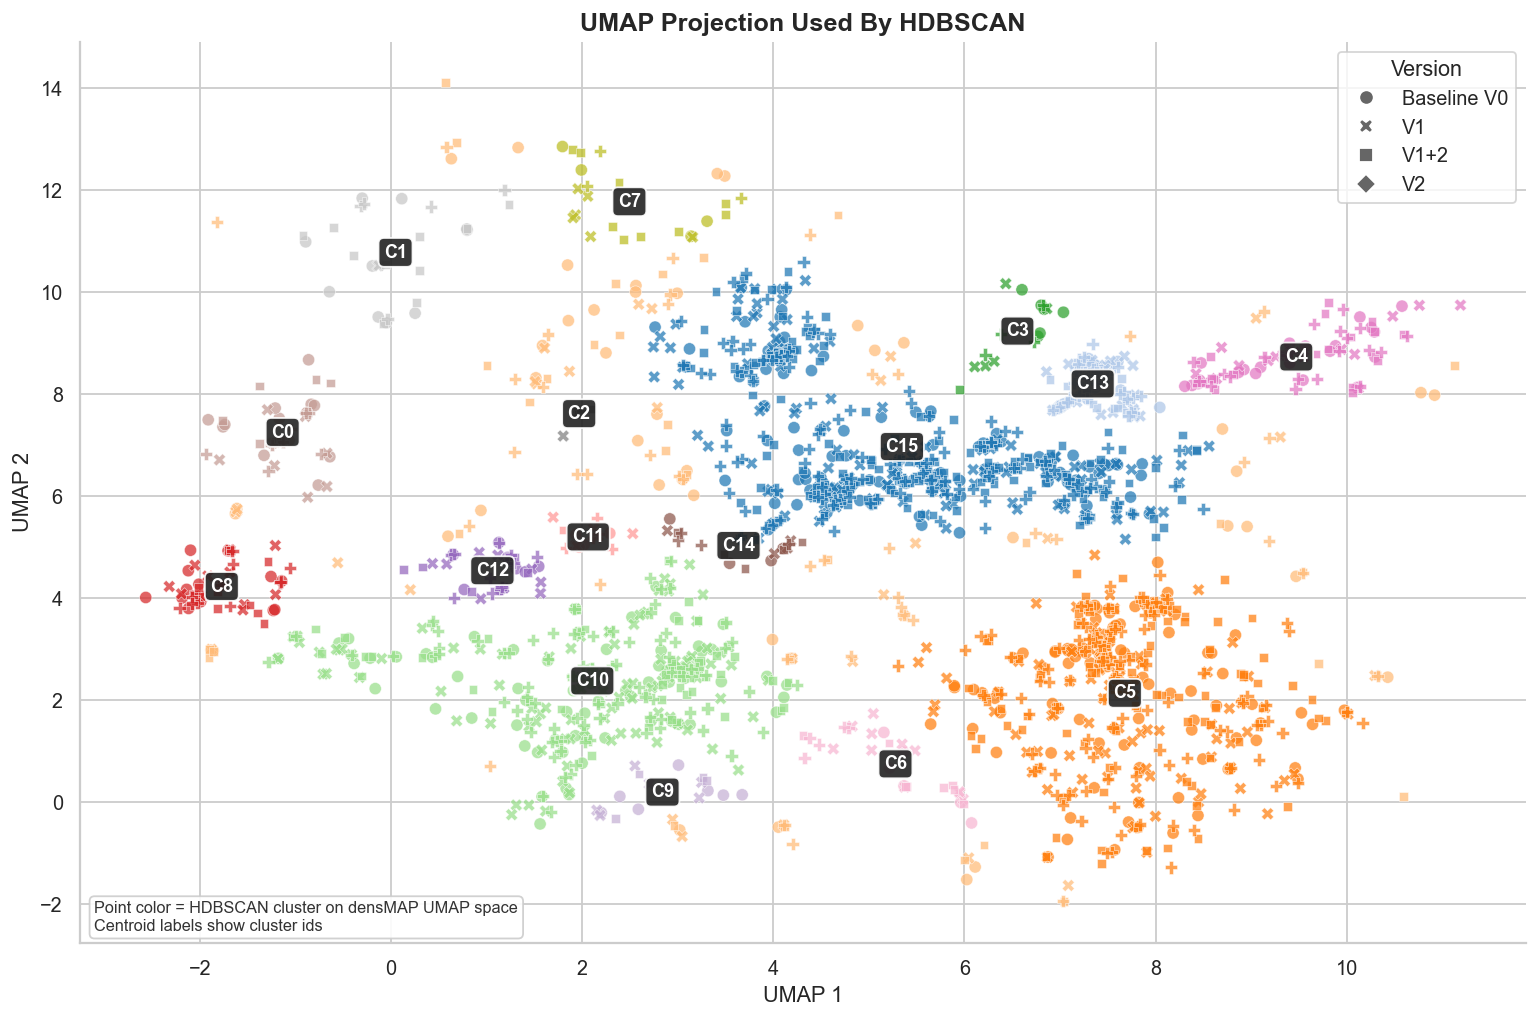

In [243]:
plot_df = cluster_df.copy()
plot_df["cluster_label_str"] = plot_df["cluster_label"].astype(str)

fig, ax = plt.subplots(figsize=(12, 8))
n_cluster_labels = plot_df["cluster_label_str"].nunique()
palette = sns.color_palette("tab20", n_colors=n_cluster_labels)
sns.scatterplot(
    data=plot_df,
    x="umap_x",
    y="umap_y",
    hue="cluster_label_str",
    style="version",
    s=46,
    palette=palette,
    alpha=0.72,
    ax=ax,
    edgecolor="white",
    linewidth=0.35,
    legend=False,
)

centroids = (
    plot_df[plot_df["cluster_label"] >= 0]
    .groupby("cluster_label", as_index=False)[["umap_x", "umap_y"]]
    .mean()
)

for row in centroids.itertuples():
    ax.text(
        row.umap_x,
        row.umap_y,
        f"C{row.cluster_label}",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#222222", edgecolor="white", alpha=0.9),
        zorder=6,
    )

version_handles = []
for version, marker in zip(sorted(plot_df["version"].unique()), ["o", "X", "s", "D", "^", "P"]):
    version_handles.append(
        plt.Line2D(
            [], [], linestyle="", marker=marker, markersize=8,
            markerfacecolor="#666666", markeredgecolor="white", label=version,
        )
    )
ax.legend(handles=version_handles, title="Version", loc="upper right")

ax.text(
    0.01, 0.01,
    "Point color = HDBSCAN cluster on densMAP UMAP space\nCentroid labels show cluster ids",
    transform=ax.transAxes,
    fontsize=9,
    color="#333333",
    ha="left",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#cccccc", alpha=0.9),
)

ax.set_title("UMAP Projection Used By HDBSCAN", fontsize=14, fontweight="bold")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

### Optional Interactive View

This view reuses the same tuned UMAP coordinates and HDBSCAN assignments from Step 4. Hover reveals the code metadata without adding text clutter to the static plot.

In [244]:
interactive_df = plot_df.copy()
interactive_df["cluster_label_str"] = interactive_df["cluster_label"].astype(str)

fig = px.scatter(
    interactive_df,
    x="umap_x",
    y="umap_y",
    color="cluster_label_str",
    symbol="version",
    hover_data={
        "version": True,
        "question_id": True,
        "tag": True,
        "code_name": True,
        "description": True,
        "cluster_label_str": False,
        "umap_x": ":.3f",
        "umap_y": ":.3f",
    },
    title="Interactive UMAP Projection of Codebook Embeddings",
    width=1050,
    height=720,
    opacity=0.8,
)
fig.update_traces(marker=dict(size=8, line=dict(width=0.4, color="white")))
fig.update_layout(legend_title_text="Cluster", template="plotly_white")
display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))

## Step 6 — Inspect HDBSCAN Output

This table summarizes the HDBSCAN result produced in Step 4 and helps verify whether similar codes across versions were grouped together, and whether some items were treated as noise (`-1`).

In [245]:
cluster_summary = (
    cluster_df.groupby(["cluster_label", "version"]).size()
    .rename("n_codes")
    .reset_index()
    .sort_values(["cluster_label", "version"])
    .reset_index(drop=True)
)

display(cluster_summary)

display(
    cluster_df.sort_values(["cluster_label", "version", "code_name"])[
        ["cluster_label", "cluster_probability", "version", "tag", "code_name", "description"]
    ]
    .reset_index(drop=True)
)

,cluster_label,version,n_codes
0,-1,Baseline V0,43
1,-1,V1,31
2,-1,V1+2,32
3,-1,V2,41
4,0,Baseline V0,13
...,...,...,...
62,14,V2,4
63,15,Baseline V0,111
64,15,V1,152
65,15,V1+2,138


,cluster_label,cluster_probability,version,tag,code_name,description
0,-1,0.0,Baseline V0,Code_9,Academic_R&D_Ecosystem,Highlights the broader role of Swiss federal i...
1,-1,0.0,Baseline V0,Code_2,Academic_Spin_Off_Origin,Highlights the company's origin as a spin-off ...
2,-1,0.0,Baseline V0,Code_4,Advanced Data & Imaging,"Describes the sophisticated data collection, i..."
3,-1,0.0,Baseline V0,Code_4,Advantages,"Positive characteristics, benefits, or strengt..."
4,-1,0.0,Baseline V0,Code_4,Advantages & Benefits,Highlights the positive aspects and strengths ...
...,...,...,...,...,...,...
1973,15,1.0,V2,Code_5,Thruster_Type_Classification,Categorization of thrusters based on their ope...
1974,15,1.0,V2,Code_6,Underlying Principle/Mechanism,Explains the fundamental physical principle or...
1975,15,1.0,V2,Code_7,User_Guidance_Identification,Advice or criteria provided to users on how to...
1976,15,1.0,V2,Code_9,Validation_and_Real_World_Testing,Evidence of the technology's practical viabili...


## Step 7 — Hierarchical Dendrogram

HDBSCAN gives the density-based grouping. The dendrogram adds a complementary hierarchical view so you can inspect which codes merge earlier or later in the embedding space.

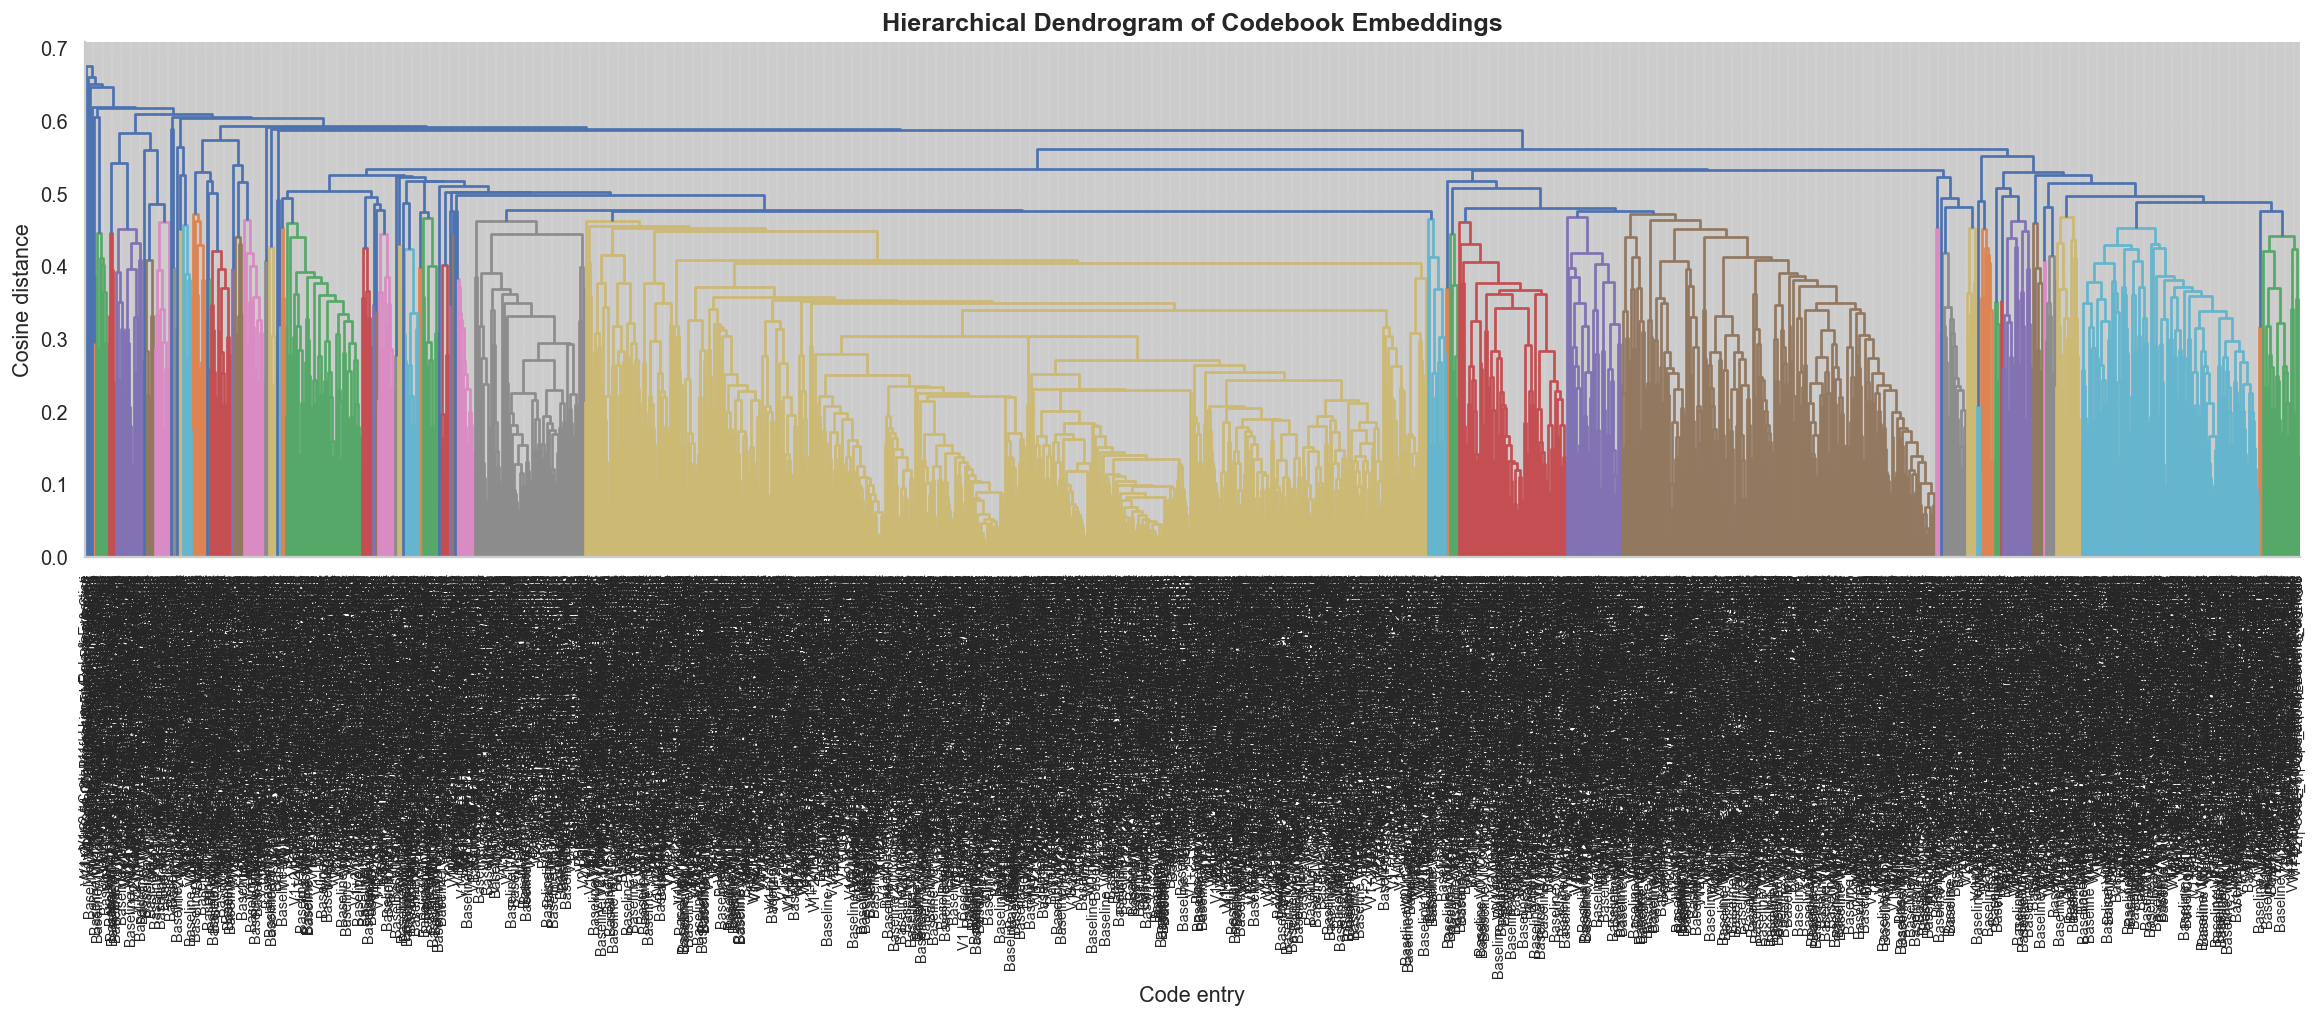

In [246]:
labels_for_tree = [
    f"{row.version} | {row.tag} | {row.code_name[:30]}"
    for row in cluster_df.itertuples()
 ]

cosine_distances = pdist(embedding_matrix, metric="cosine")
linkage_matrix = linkage(cosine_distances, method="average")

fig, ax = plt.subplots(figsize=(18, 8))
dendrogram(
    linkage_matrix,
    labels=labels_for_tree,
    leaf_rotation=90,
    leaf_font_size=8,
    above_threshold_color="#4C72B0",
    ax=ax,
)
ax.set_title("Hierarchical Dendrogram of Codebook Embeddings", fontsize=14, fontweight="bold")
ax.set_xlabel("Code entry")
ax.set_ylabel("Cosine distance")
plt.tight_layout()
plt.show()

## Step 8 — Cluster Catalog Dashboard

This section turns the tuned HDBSCAN output into a readable cluster catalog. Each card summarizes one cluster with its size, version mix, and the codes that belong to it.

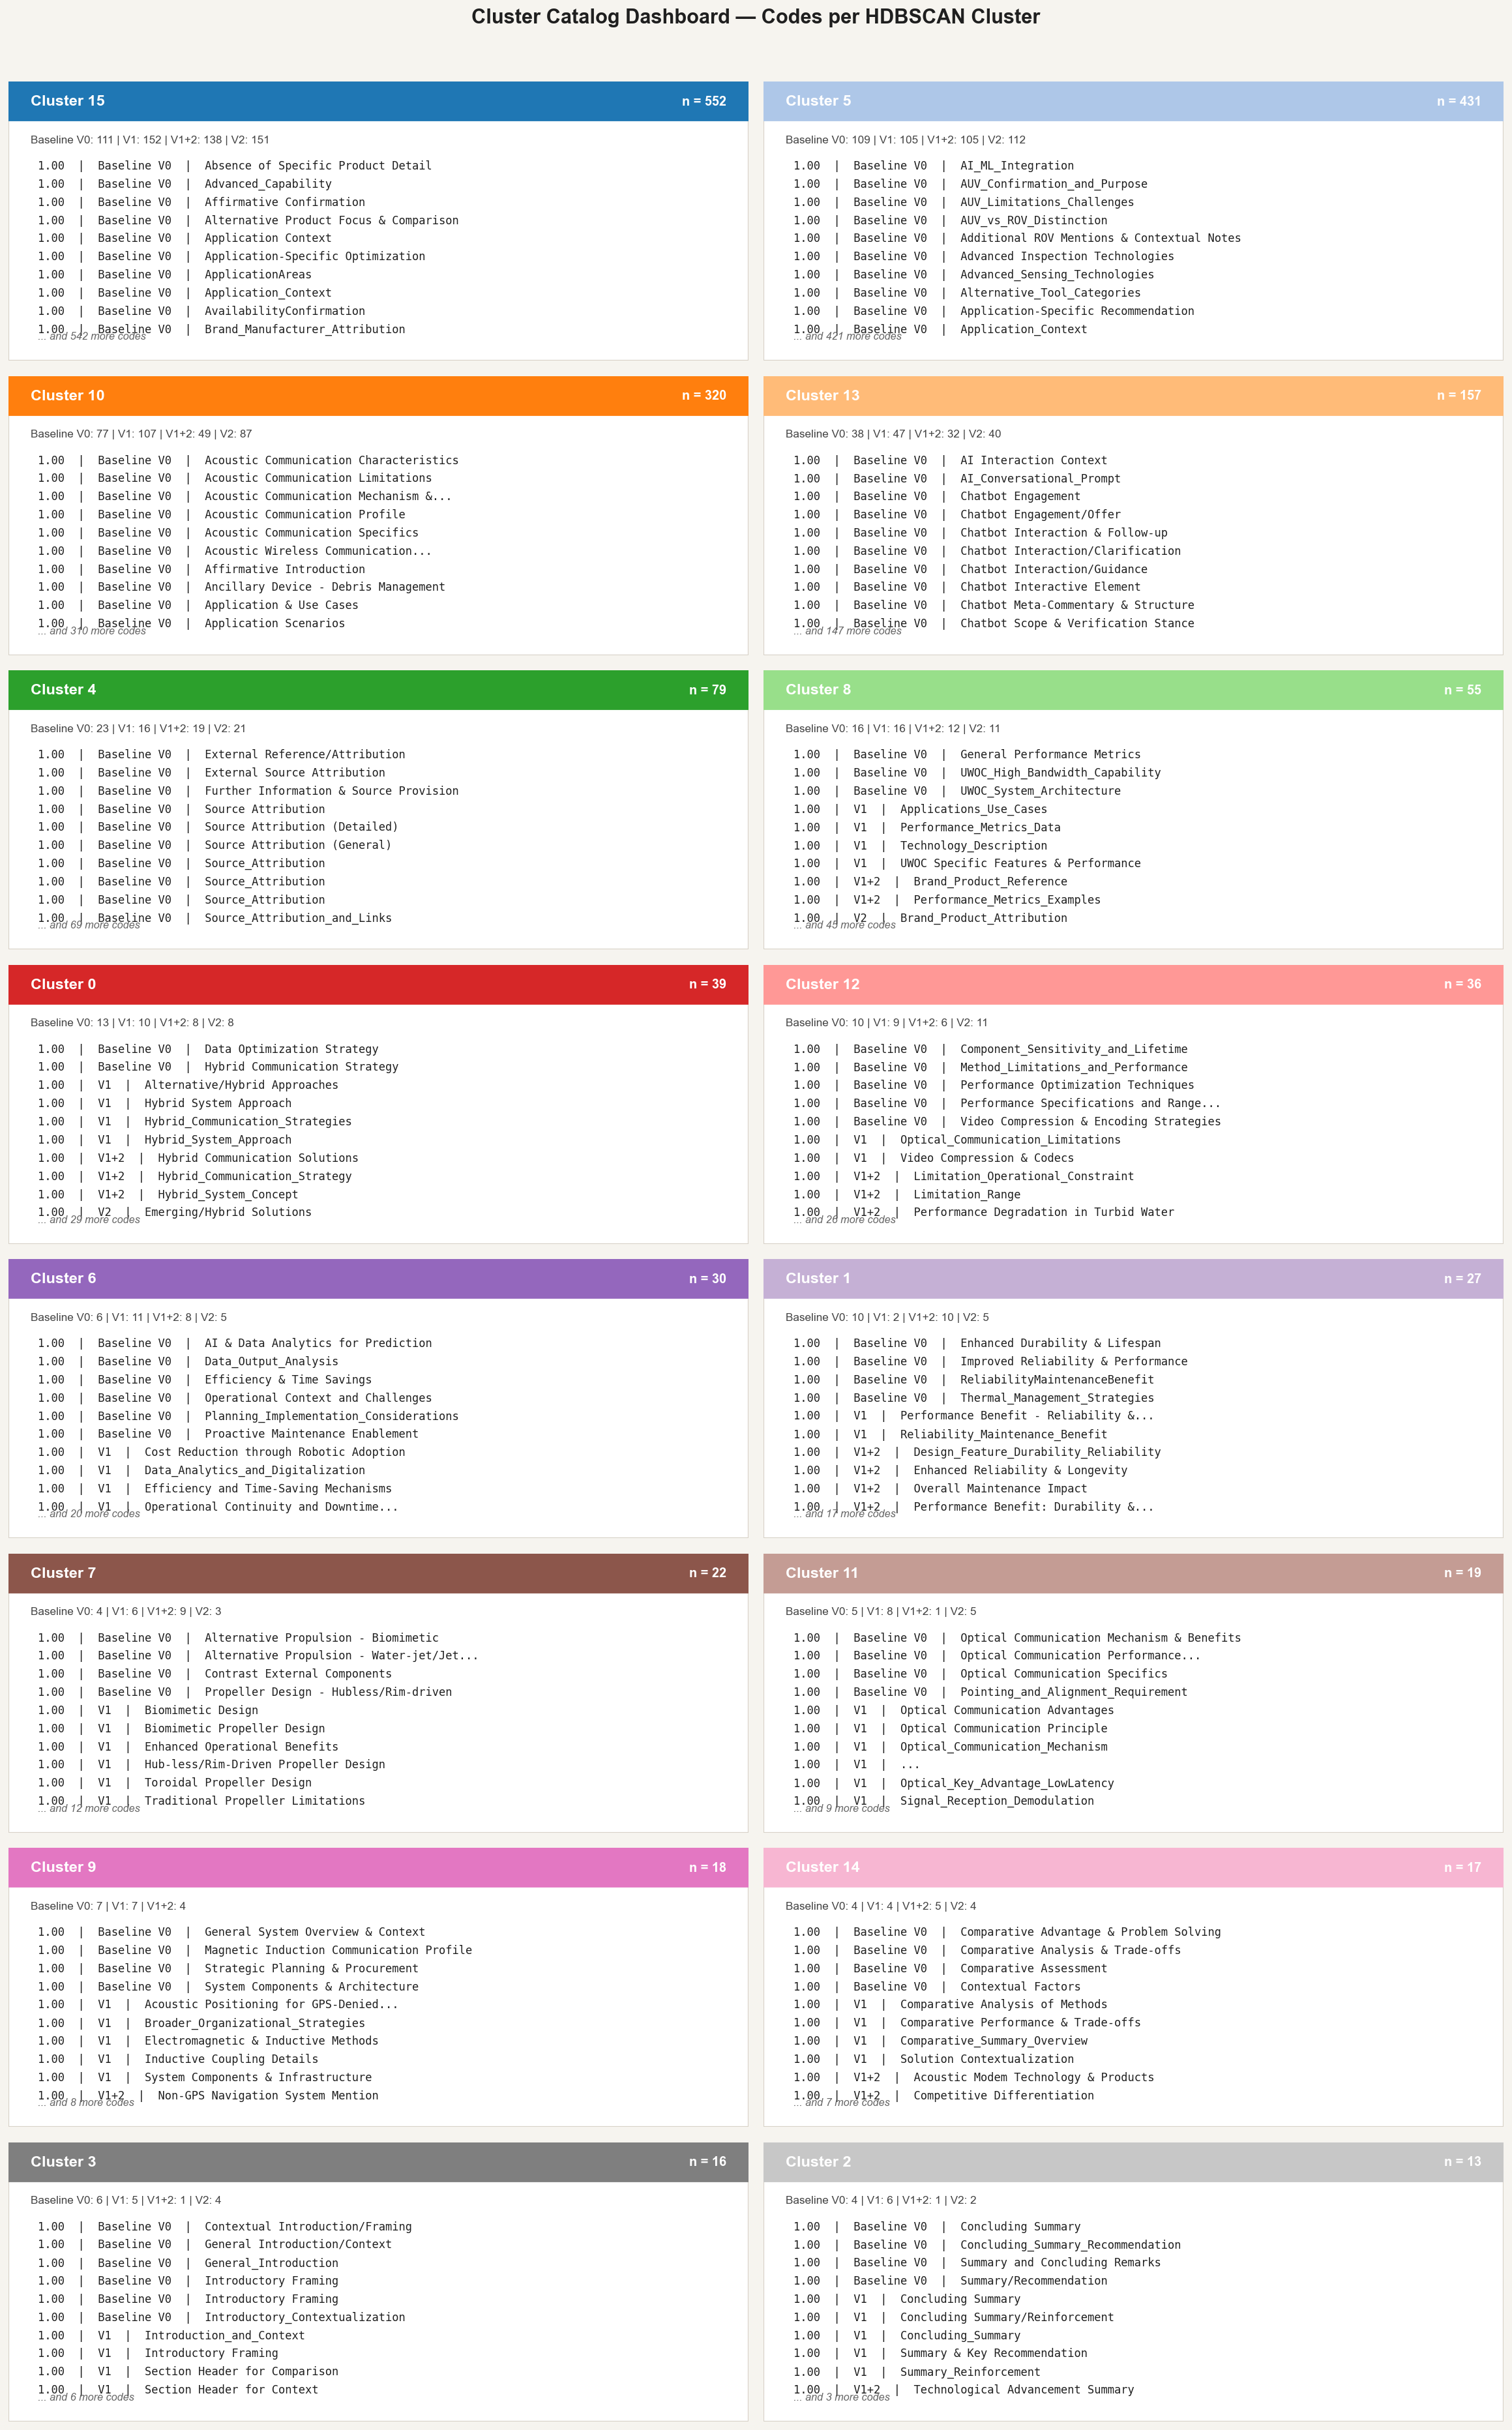

,cluster_label,cluster_probability,version,tag,code_name,description
0,0,1.000000,Baseline V0,Code_10,Data Optimization Strategy,Methods or techniques focused on improving the...
1,0,1.000000,Baseline V0,Code_7,Hybrid Communication Strategy,Describes the approach of combining different ...
2,0,1.000000,V1,Code_12,Alternative/Hybrid Approaches,"Discussion of less common, experimental, or co..."
3,0,1.000000,V1,Code_8,Hybrid System Approach,Suggests combining multiple communication tech...
4,0,1.000000,V1,Code_14,Hybrid_Communication_Strategies,Describes approaches that combine two or more ...
...,...,...,...,...,...,...
1826,15,0.897952,V2,Code_11,Comparative Table Header,"The header row of a comparative table, definin..."
1827,15,0.897952,V2,Code_12,Product Evolution and Performance Comparison,The AI describes the development or evolution ...
1828,15,0.893399,V1,Code_7,Control and Optimization Mechanisms,"Reference to advanced control systems, algorit..."
1829,15,0.893399,V1,Code_6,Surface Treatment/Coating,Covers solutions that involve applying coating...


In [247]:
from textwrap import shorten
import math

catalog_df = cluster_df[cluster_df["cluster_label"] >= 0].copy()

if catalog_df.empty:
    print("No non-noise clusters to display.")
else:
    cluster_order = (
        catalog_df.groupby("cluster_label").size()
        .sort_values(ascending=False)
        .index.tolist()
    )

    n_cols = 2
    n_rows = math.ceil(len(cluster_order) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, max(5, n_rows * 3.6)))
    fig.patch.set_facecolor("#f6f4ef")
    axes = np.atleast_1d(axes).flatten()
    palette = sns.color_palette("tab20", n_colors=max(20, len(cluster_order)))

    for ax in axes:
        ax.axis("off")
        ax.set_facecolor("#f6f4ef")

    for idx, cluster_id in enumerate(cluster_order):
        ax = axes[idx]
        subset = catalog_df[catalog_df["cluster_label"] == cluster_id].copy()
        subset = subset.sort_values(
            ["cluster_probability", "version", "code_name"],
            ascending=[False, True, True],
        ).reset_index(drop=True)

        version_counts = subset["version"].value_counts().sort_index()
        version_line = " | ".join([f"{version}: {count}" for version, count in version_counts.items()])
        card_color = palette[idx % len(palette)]

        ax.add_patch(
            plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, facecolor="white",
                          edgecolor="#d7d1c7", linewidth=1.2, zorder=0)
        )
        ax.add_patch(
            plt.Rectangle((0, 0.86), 1, 0.14, transform=ax.transAxes, facecolor=card_color,
                          edgecolor=card_color, zorder=1)
        )

        ax.text(
            0.03, 0.93,
            f"Cluster {cluster_id}",
            transform=ax.transAxes,
            ha="left", va="center",
            fontsize=13, fontweight="bold", color="white",
        )
        ax.text(
            0.97, 0.93,
            f"n = {len(subset)}",
            transform=ax.transAxes,
            ha="right", va="center",
            fontsize=11, fontweight="bold", color="white",
        )

        ax.text(
            0.03, 0.81,
            version_line,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=9.5, color="#444444",
        )

        y = 0.72
        max_items = min(10, len(subset))
        for row in subset.head(max_items).itertuples():
            line = (
                f"{row.cluster_probability:0.2f}  |  {row.version}  |  "
                f"{shorten(row.code_name, width=42, placeholder='...')}"
            )
            ax.text(
                0.04, y, line,
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=9.5, color="#1f1f1f", family="monospace",
            )
            y -= 0.065

        remaining = len(subset) - max_items
        if remaining > 0:
            ax.text(
                0.04, max(y, 0.05),
                f"... and {remaining} more codes",
                transform=ax.transAxes,
                ha="left", va="bottom",
                fontsize=9, color="#666666", style="italic",
            )

    for ax in axes[len(cluster_order):]:
        ax.set_visible(False)

    fig.suptitle(
        "Cluster Catalog Dashboard — Codes per HDBSCAN Cluster",
        fontsize=17, fontweight="bold", y=0.995, color="#1f1f1f",
    )
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

    display(
        catalog_df.sort_values(["cluster_label", "cluster_probability", "version", "code_name"], ascending=[True, False, True, True])[
            ["cluster_label", "cluster_probability", "version", "tag", "code_name", "description"]
        ].reset_index(drop=True)
    )

In [248]:
## Step 9 — Export Dendrogram Analysis Bundle

# This step writes a reusable export bundle for the Streamlit app, including the projected points, cluster assignments, cluster summaries, and dendrogram tree.

In [249]:
from datetime import datetime, timezone

EXPORT_DIR = DATA_ROOT / "ALL_VERSIONS" / "dendrogram_analysis"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

if "linkage_matrix" not in globals():
    linkage_matrix = linkage(pdist(embedding_matrix, metric="cosine"), method="average")

if "labels_for_tree" not in globals():
    labels_for_tree = [
        f"{row.version} | {row.tag} | {row.code_name[:30]}"
        for row in cluster_df.itertuples()
    ]

manifest_payload = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "scope": "ALL_VERSIONS",
    "model_name": MODEL_NAME,
    "n_records": int(len(cluster_df)),
    "n_clusters_excluding_noise": int(len({label for label in cluster_df["cluster_label"] if label >= 0})),
    "noise_ratio": float((cluster_df["cluster_label"] == -1).mean()),
    "versions": sorted(cluster_df["version"].dropna().unique().tolist()),
    "umap": {
        "n_components": int(UMAP_N_COMPONENTS),
        "n_neighbors": int(UMAP_N_NEIGHBORS),
        "min_dist": float(UMAP_MIN_DIST),
        "metric": UMAP_METRIC,
        "densmap": bool(DENSE_PROJECTION),
    },
    "hdbscan": {
        "min_cluster_size": int(HDBSCAN_MIN_CLUSTER_SIZE),
        "min_samples": int(HDBSCAN_MIN_SAMPLES),
        "cluster_selection_epsilon": float(getattr(clusterer, "cluster_selection_epsilon", 0.0)),
        "relative_validity": float(getattr(clusterer, "relative_validity_", -1.0)),
    },
}

points_export_cols = [
    "code_uid",
    "version",
    "question_id",
    "tag",
    "code_name",
    "description",
    "representative_excerpt",
    "cluster_label",
    "cluster_probability",
    "umap_x",
    "umap_y",
]
points_payload = cluster_df[points_export_cols].copy().to_dict(orient="records")

cluster_summary_payload = []
for cluster_id, subset in cluster_df[cluster_df["cluster_label"] >= 0].groupby("cluster_label"):
    subset = subset.sort_values(["cluster_probability", "version", "code_name"], ascending=[False, True, True])
    cluster_summary_payload.append({
        "cluster_label": int(cluster_id),
        "size": int(len(subset)),
        "mean_probability": float(subset["cluster_probability"].mean()),
        "centroid_x": float(subset["umap_x"].mean()),
        "centroid_y": float(subset["umap_y"].mean()),
        "version_counts": {key: int(value) for key, value in subset["version"].value_counts().sort_index().items()},
        "top_codes": subset[["version", "tag", "code_name", "cluster_probability"]].head(8).to_dict(orient="records"),
    })
cluster_summary_payload = sorted(cluster_summary_payload, key=lambda item: (-item["size"], item["cluster_label"]))

dendrogram_payload = {
    "linkage_matrix": np.asarray(linkage_matrix, dtype=float).tolist(),
    "leaf_labels": list(labels_for_tree),
}

bundle_payload = {
    "manifest": manifest_payload,
    "points": points_payload,
    "cluster_summary": cluster_summary_payload,
    "dendrogram": dendrogram_payload,
}

write_json(EXPORT_DIR / "manifest.json", manifest_payload)
write_json(EXPORT_DIR / "points.json", {"points": points_payload})
write_json(EXPORT_DIR / "cluster_summary.json", {"clusters": cluster_summary_payload})
write_json(EXPORT_DIR / "dendrogram.json", dendrogram_payload)
write_json(EXPORT_DIR / "bundle.json", bundle_payload)

print(f"Exported dendrogram analysis bundle to: {EXPORT_DIR}")
print(f"Points exported: {len(points_payload)}")
print(f"Clusters exported: {len(cluster_summary_payload)}")

Exported dendrogram analysis bundle to: /Users/adnenkhiari/Documents/nawnaw/data/ALL_VERSIONS/dendrogram_analysis
Points exported: 1978
Clusters exported: 16
